In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [189]:
df = pd.read_excel('Nilai Produksi Perikanan Budidaya Menurut Provinsi dan Jenis Budidaya, 2024.xlsx')
# Menghapus baris pertama
data_clean = df.iloc[1:39].copy()
data_clean.head()

,38 Provinsi,Jaring Apung Laut,Jaring Apung Tawar,Jaring Tancap Tawar,Karamba,Kolam Air Deras,Kolam Air Tenang,Laut Lainnya,Minapadi Sawah,Rumput Laut,Tambak Intensif,Tambak Sederhana,Tambak Semi Intensif,Jumlah
1,ACEH,14288899,29783695,1552730,2824922,1268000,726106594,0,17350838,0,974209855,2297075679,477889633,4542350845
2,SUMATERA UTARA,15708890,896244639,1874014,42062786,6486574,6779502682,13620125,498963520,15900,867684895,840827464,792885715,10755877204
3,SUMATERA BARAT,35048990,381468429,24226520,147241122,882870065,5133856718,0,29682343,93699,400736920,0,0,7035224806
4,RIAU,14168100,241286294,2047870,483516283,0,1808861259,125076000,0,0,464263293,113723975,60500,3253003574
5,JAMBI,0,411051884,1506890,1298785,294863,701425094,0,1339455,0,0,9524075,0,1126441046


In [190]:
data_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 1 to 38
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   38 Provinsi           38 non-null     str  
 1   Jaring Apung Laut     38 non-null     int64
 2   Jaring Apung Tawar    38 non-null     int64
 3   Jaring Tancap Tawar   38 non-null     int64
 4   Karamba               38 non-null     int64
 5   Kolam Air Deras       38 non-null     int64
 6   Kolam Air Tenang      38 non-null     int64
 7   Laut Lainnya          38 non-null     int64
 8   Minapadi Sawah        38 non-null     int64
 9   Rumput Laut           38 non-null     int64
 10  Tambak Intensif       38 non-null     int64
 11  Tambak Sederhana      38 non-null     int64
 12  Tambak Semi Intensif  38 non-null     int64
 13  Jumlah                38 non-null     int64
dtypes: int64(13), str(1)
memory usage: 4.3 KB


In [191]:
kolom_pilihan = ['Kolam Air Tenang', 'Tambak Intensif', 'Tambak Sederhana', 'Jumlah']
data = data_clean[kolom_pilihan].copy()

In [192]:
for col in kolom_pilihan:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Mengganti nilai 0 dengan rata-rata
data_temporary = data.replace(0, np.nan)
rata_rata_murni = data_temporary.mean(numeric_only=True)
data = data_temporary.fillna(rata_rata_murni)

In [193]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 1 to 38
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Kolam Air Tenang  38 non-null     int64  
 1   Tambak Intensif   38 non-null     float64
 2   Tambak Sederhana  38 non-null     float64
 3   Jumlah            38 non-null     int64  
dtypes: float64(2), int64(2)
memory usage: 1.3 KB


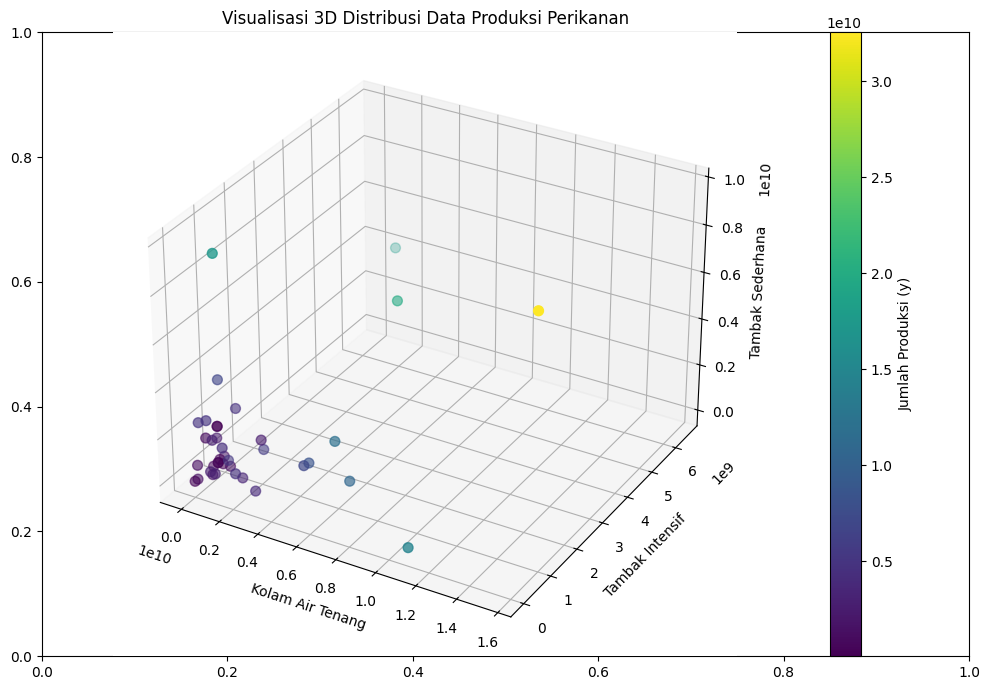

In [194]:
fig = plt.subplots(figsize=(10, 7))
ax = plt.axes(projection='3d')

x1 = data['Kolam Air Tenang']
x2 = data['Tambak Intensif']
x3 = data['Tambak Sederhana']
y = data['Jumlah']

sc = ax.scatter3D(x1, x2, x3, c=y, cmap='viridis', s=50)

ax.set_xlabel('Kolam Air Tenang')
ax.set_ylabel('Tambak Intensif')
ax.set_zlabel('Tambak Sederhana')

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('Jumlah Produksi (y)')

plt.title('Visualisasi 3D Distribusi Data Produksi Perikanan')
plt.tight_layout()
plt.show()

In [195]:
X = data[['Kolam Air Tenang', 'Tambak Intensif', 'Tambak Sederhana']]
X.head()

,Kolam Air Tenang,Tambak Intensif,Tambak Sederhana
1,726106594,9.742099e+08,2.297076e+09
2,6779502682,8.676849e+08,8.408275e+08
3,5133856718,4.007369e+08,1.585017e+09
4,1808861259,4.642633e+08,1.137240e+08
5,701425094,7.571014e+08,9.524075e+06


In [196]:
y.head()

1     4542350845
2    10755877204
3     7035224806
4     3253003574
5     1126441046
Name: Jumlah, dtype: int64

In [197]:
regr = linear_model.LinearRegression()
regr.fit(X, y)

konstanta = regr.intercept_
koef_kolam = regr.coef_[0]
koef_intensif = regr.coef_[1]
koef_sederhana = regr.coef_[2]
r_square = regr.score(X, y)

In [198]:
print("=================================================================")
print("             EVALUASI AKURASI MODEL (R-SQUARED)                  ")
print("=================================================================")
print(f"Nilai R-squared (R²)      : {r_square:.6f}")
print(f"Koefisien Determinasi (%) : {r_square * 100:.2f}%")
print("-----------------------------------------------------------------")
print("Interpretasi Akademik Proyek UAS:")
print(f"Sebesar {r_square * 100:.2f}% variasi dari 'Total Jumlah Produksi Perikanan'")
print("dapat dijelaskan secara bersama-sama oleh variabel Kolam Air Tenang,")
print("Tambak Intensif, dan Tambak Sederhana.")
print(f"Sedangkan sisanya yaitu sebesar {(1 - r_square) * 100:.2f}% dijelaskan oleh")
print("jenis budidaya lainnya atau faktor lain di luar model regresi.")
print("=================================================================\n")

             EVALUASI AKURASI MODEL (R-SQUARED)                  
Nilai R-squared (R²)      : 0.954658
Koefisien Determinasi (%) : 95.47%
-----------------------------------------------------------------
Interpretasi Akademik Proyek UAS:
Sebesar 95.47% variasi dari 'Total Jumlah Produksi Perikanan'
dapat dijelaskan secara bersama-sama oleh variabel Kolam Air Tenang,
Tambak Intensif, dan Tambak Sederhana.
Sedangkan sisanya yaitu sebesar 4.53% dijelaskan oleh
jenis budidaya lainnya atau faktor lain di luar model regresi.



In [199]:
print("=================================================================")
print("               PARAMETER MODEL REGRESI                           ")
print("=================================================================")
print(f"Konstanta (a)                 : {konstanta:.4f}")
print(f"Koefisien Kolam Air Tenang (b1): {koef_kolam:.4f}")
print(f"Koefisien Tambak Intensif (b2) : {koef_intensif:.4f}")
print(f"Koefisien Tambak Sederhana (b3): {koef_sederhana:.4f}")
print("\nPersamaan Matematika Regresi Berganda:")
print(f"Y (Jumlah) = {konstanta:.4f} + ({koef_kolam:.4f} * X1) + ({koef_intensif:.4f} * X2) + ({koef_sederhana:.4f} * X3)")
print("=================================================================\n")

               PARAMETER MODEL REGRESI                           
Konstanta (a)                 : -234216581.3607
Koefisien Kolam Air Tenang (b1): 1.1653
Koefisien Tambak Intensif (b2) : 1.4695
Koefisien Tambak Sederhana (b3): 1.4934

Persamaan Matematika Regresi Berganda:
Y (Jumlah) = -234216581.3607 + (1.1653 * X1) + (1.4695 * X2) + (1.4934 * X3)



In [200]:
# Fungsi Prediksi Otomatis
def hitung_prediksi_produksi(kolam, intensif, sederhana):
    prediksi = konstanta + (koef_kolam * kolam) + (koef_intensif * intensif) + (koef_sederhana * sederhana)
    return prediksi

In [201]:
kolam_1, intensif_1, sederhana_1 = 500000000, 700000000, 1500000000
hasil_1 = hitung_prediksi_produksi(kolam_1, intensif_1, sederhana_1)

print("=================================================================")
print("             PREDIKSI JUMLAH PRODUKSI BARU (SKENARIO 1)        ")
print("=================================================================")
print(f"Input Kolam Air Tenang (X1) : {kolam_1:,}")
print(f"Input Tambak Intensif (X2)  : {intensif_1:,}")
print(f"Input Tambak Sederhana (X3) : {sederhana_1:,}")
print(f"Estimasi Hasil Jumlah (Y)   : {hasil_1:,.2f}")
print("=================================================================\n")

             PREDIKSI JUMLAH PRODUKSI BARU (SKENARIO 1)        
Input Kolam Air Tenang (X1) : 500,000,000
Input Tambak Intensif (X2)  : 700,000,000
Input Tambak Sederhana (X3) : 1,500,000,000
Estimasi Hasil Jumlah (Y)   : 3,617,235,768.36



In [202]:
kolam_2, intensif_2, sederhana_2 = 200000000, 500000000, 1000000000
hasil_2 = hitung_prediksi_produksi(kolam_2, intensif_2, sederhana_2)

print("=================================================================")
print("             PREDIKSI JUMLAH PRODUKSI BARU (SKENARIO 2)        ")
print("=================================================================")
print(f"Input Kolam Air Tenang (X1) : {kolam_2:,}")
print(f"Input Tambak Intensif (X2)  : {intensif_2:,}")
print(f"Input Tambak Sederhana (X3) : {sederhana_2:,}")
print(f"Estimasi Hasil Jumlah (Y)   : {hasil_2:,.2f}")
print("=================================================================\n")

             PREDIKSI JUMLAH PRODUKSI BARU (SKENARIO 2)        
Input Kolam Air Tenang (X1) : 200,000,000
Input Tambak Intensif (X2)  : 500,000,000
Input Tambak Sederhana (X3) : 1,000,000,000
Estimasi Hasil Jumlah (Y)   : 2,227,035,160.31



In [203]:
kolam_3, intensif_3, sederhana_3 = 300000000, 600000000, 1200000000
hasil_3 = hitung_prediksi_produksi(kolam_3, intensif_3, sederhana_3)

print("=================================================================")
print("             PREDIKSI JUMLAH PRODUKSI BARU (SKENARIO 2)        ")
print("=================================================================")
print(f"Input Kolam Air Tenang (X1) : {kolam_2:,}")
print(f"Input Tambak Intensif (X2)  : {intensif_2:,}")
print(f"Input Tambak Sederhana (X3) : {sederhana_2:,}")
print(f"Estimasi Hasil Jumlah (Y)   : {hasil_2:,.2f}")
print("=================================================================\n")

             PREDIKSI JUMLAH PRODUKSI BARU (SKENARIO 2)        
Input Kolam Air Tenang (X1) : 200,000,000
Input Tambak Intensif (X2)  : 500,000,000
Input Tambak Sederhana (X3) : 1,000,000,000
Estimasi Hasil Jumlah (Y)   : 2,227,035,160.31

